# Phân tích mối quan hệ giữa các đặc tính sản phẩm và hiệu quả bán hàng
## Thành viên thực hiện: My

# 1. GIỚI THIỆU

Trong bối cảnh thương mại điện tử phát triển nhanh chóng, việc tối ưu hóa chiến lược giá (pricing) và khuyến mãi (promotion) đóng vai trò quan trọng trong việc nâng cao hiệu quả kinh doanh. Các nền tảng TMĐT không chỉ cần tối đa hóa lượt bán (sales volume) mà còn phải đảm bảo giá trị doanh thu (revenue), đồng thời cân bằng giữa hai mục tiêu này.

Tuy nhiên, mối quan hệ giữa **mức giá**, **tỷ lệ giảm giá** và **hành vi mua hàng** không đơn giản và có thể thay đổi tùy theo từng ngành hàng. Việc hiểu rõ các mối quan hệ này là nền tảng để xây dựng chiến lược kinh doanh hiệu quả dựa trên dữ liệu.

---

# 2. MỤC TIÊU PHÂN TÍCH

Bài phân tích này nhằm trả lời hai câu hỏi chính:

### Mục tiêu 1: Tác động của phân khúc giá đến hiệu quả bán hàng
Phân khúc giá ảnh hưởng như thế nào đến hiệu quả bán hàng (lượt bán và doanh thu), và liệu tác động này có nhất quán giữa số lượng và giá trị hay không?

---

### Mục tiêu 2: Tác động của tỷ lệ giảm giá đến việc kích cầu
Tỷ lệ giảm giá ảnh hưởng như thế nào đến việc kích cầu (lượt bán) và liệu hiệu quả này có khác biệt giữa các mức giảm giá và giữa các ngành hàng hay không?

---

# 3. PHƯƠNG PHÁP

Phân tích được thực hiện thông qua các bước trực quan hóa dữ liệu (data visualization), với logic từ tổng quan đến chi tiết:

- **Bar Chart**: xác định xu hướng tổng thể  
- **Boxplot**: kiểm chứng phân phối và độ ổn định  
- **Grouped Bar / Heatmap**: giải thích theo ngành hàng  

Cách tiếp cận này giúp đảm bảo rằng các kết luận được xây dựng dựa trên dữ liệu quan sát, đồng thời hạn chế các suy đoán không có cơ sở.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

## 1. Tải dữ liệu 

In [2]:
df_store    = pd.read_csv('../data/stores.csv')
df_category = pd.read_csv('../data/categories.csv')
df_product  = pd.read_csv('../data/products.csv')
df_review   = pd.read_csv('../data/reviews.csv')
df_product_raw  = pd.read_csv('../data/products.csv') 

print("=== DỮ LIỆU GỐC ===")
print(df_product_raw[['price', 'sold_count']].describe())

q_sold = df_product_raw['sold_count'].quantile(0.99)
q_price = df_product_raw['price'].quantile(0.99)

df_product = df_product_raw[
    (df_product_raw['sold_count'] < q_sold) & 
    (df_product_raw['price'] < q_price)
].copy()

print("\n=== SAU KHI LOẠI BỎ 1% NGOẠI LAI CAO NHẤT ===")
print(df_product[['price', 'sold_count']].describe())


=== DỮ LIỆU GỐC ===
              price    sold_count
count  5.588300e+04  55883.000000
mean   2.377133e+06     18.562532
std    1.112896e+07    286.145064
min    1.800000e+03      0.000000
25%    8.900000e+04      0.000000
50%    3.096000e+05      0.000000
75%    1.250000e+06      2.000000
max    8.178840e+08  24614.000000

=== SAU KHI LOẠI BỎ 1% NGOẠI LAI CAO NHẤT ===
              price    sold_count
count  5.476500e+04  54765.000000
mean   1.724946e+06      4.832064
std    3.907106e+06     18.499714
min    1.800000e+03      0.000000
25%    8.500000e+04      0.000000
50%    3.000000e+05      0.000000
75%    1.190000e+06      2.000000
max    3.141525e+07    235.000000


## 2. Mục tiêu 1: Tác động của phân khúc giá đến hiệu quả bán hàng
Phân khúc giá ảnh hưởng như thế nào đến hiệu quả bán hàng (lượt bán và doanh thu) và liệu tác động này có nhất quán giữa số lượng và giá trị hay không?


## Xác định mục tiêu theo nguyên tắc SMART ##
- Specific: Xác định phân khúc giá tối ưu để đạt lượt bán cao nhất trên phạm vi toàn bộ 5 ngành hàng chính của dataset.

- Measurable: Đo lường thông qua các chỉ số: lượt bán trung bình (avg_sold), tổng doanh thu (revenue_B) và kiểm chứng bằng hệ số tương quan Spearman.

- Achievable: Khả thi dựa trên việc phân nhóm (binning) và xử lý 55,883 bản ghi từ tập dữ liệu thực tế.

- Relevant: Làm rõ chiến lược định giá để tối ưu hóa vị thế cạnh tranh cho nhà bán hàng trên sàn TMĐT.

- Time-bound: Phân tích dựa trên snapshot dữ liệu hiện tại, phản ánh các xu hướng kinh doanh trong một chu kỳ báo cáo cố định nhằm đảm bảo tính nhất quán của các kết luận thống kê trước thời hạn hoàn thành bài Lab.

In [3]:

category_mapping = {
    'diengiadung': 'Điện gia dụng',
    'dientu_dienlanh': 'Điện tử - Điện lạnh',
    'dienthoai_maytinhbang': 'Điện thoại - Máy tính bảng',
    'laptop_mayvitinh_linhkien': 'Laptop - Máy tính - Linh kiện',
    'thietbiso_phukienso': 'Thiết bị số - Phụ kiện số'
} 

cat_colors = {
    'Điện gia dụng': '#2196F3',
    'Điện tử - Điện lạnh': '#4CAF50',
    'Điện thoại - Máy tính bảng': '#FF9800',
    'Laptop - Máy tính - Linh kiện': '#E91E63',
    'Thiết bị số - Phụ kiện số': '#9C27B0'
}


In [4]:
df_my_01 = df_product.copy()

df_my_01 = pd.merge(df_my_01, df_category[['category_id', 'source_category']], on='category_id', how='left')

df_my_01 = df_my_01[
    (df_my_01['price'] > 0) & 
    (df_my_01['source_category'].notna())
].copy()

df_my_01['category_name'] = df_my_01['source_category'].map(category_mapping)

df_my_01 = df_my_01[df_my_01['category_name'].notna()]

df_my_01['price_segment'] = pd.cut(
    df_my_01['price'],
    bins=[0, 50000, 200000, 1000000, 5000000, float('inf')],
    labels=['<50K', '50K–200K', '200K–1M', '1M–5M', '>5M']
)

df_my_01['est_revenue'] = df_my_01['price'] * df_my_01['sold_count']

print(f"Tổng số sản phẩm đưa vào phân tích: {len(df_my_01)}")
print(f"\nPhân bố theo ngành hàng:\n{df_my_01['category_name'].value_counts()}")

df_my_02 = df_my_01.groupby('price_segment', observed=True).agg(
    product_count=('product_id', 'count'),
    avg_sold=('sold_count', 'mean'),
    total_sold=('sold_count', 'sum'),
    total_revenue=('est_revenue', 'sum')
).reset_index()

df_my_02['revenue_B'] = df_my_02['total_revenue'] / 1e9
print("=== Bảng thống kê tóm tắt theo phân khúc giá ===")
print(df_my_02)

Tổng số sản phẩm đưa vào phân tích: 54765

Phân bố theo ngành hàng:
category_name
Thiết bị số - Phụ kiện số        30236
Điện gia dụng                    11531
Laptop - Máy tính - Linh kiện    11029
Điện tử - Điện lạnh               1827
Điện thoại - Máy tính bảng         142
Name: count, dtype: int64
=== Bảng thống kê tóm tắt theo phân khúc giá ===
  price_segment  product_count  avg_sold  total_sold  total_revenue  revenue_B
0          <50K           9204  2.491743       22934      775718912   0.775719
1      50K–200K          12770  7.996006      102109    12482570674  12.482571
2       200K–1M          18037  5.616012      101296    46945364876  46.945365
3         1M–5M           9647  3.568674       34427    71339297343  71.339297
4           >5M           5107  0.756217        3862    32337914223  32.337914


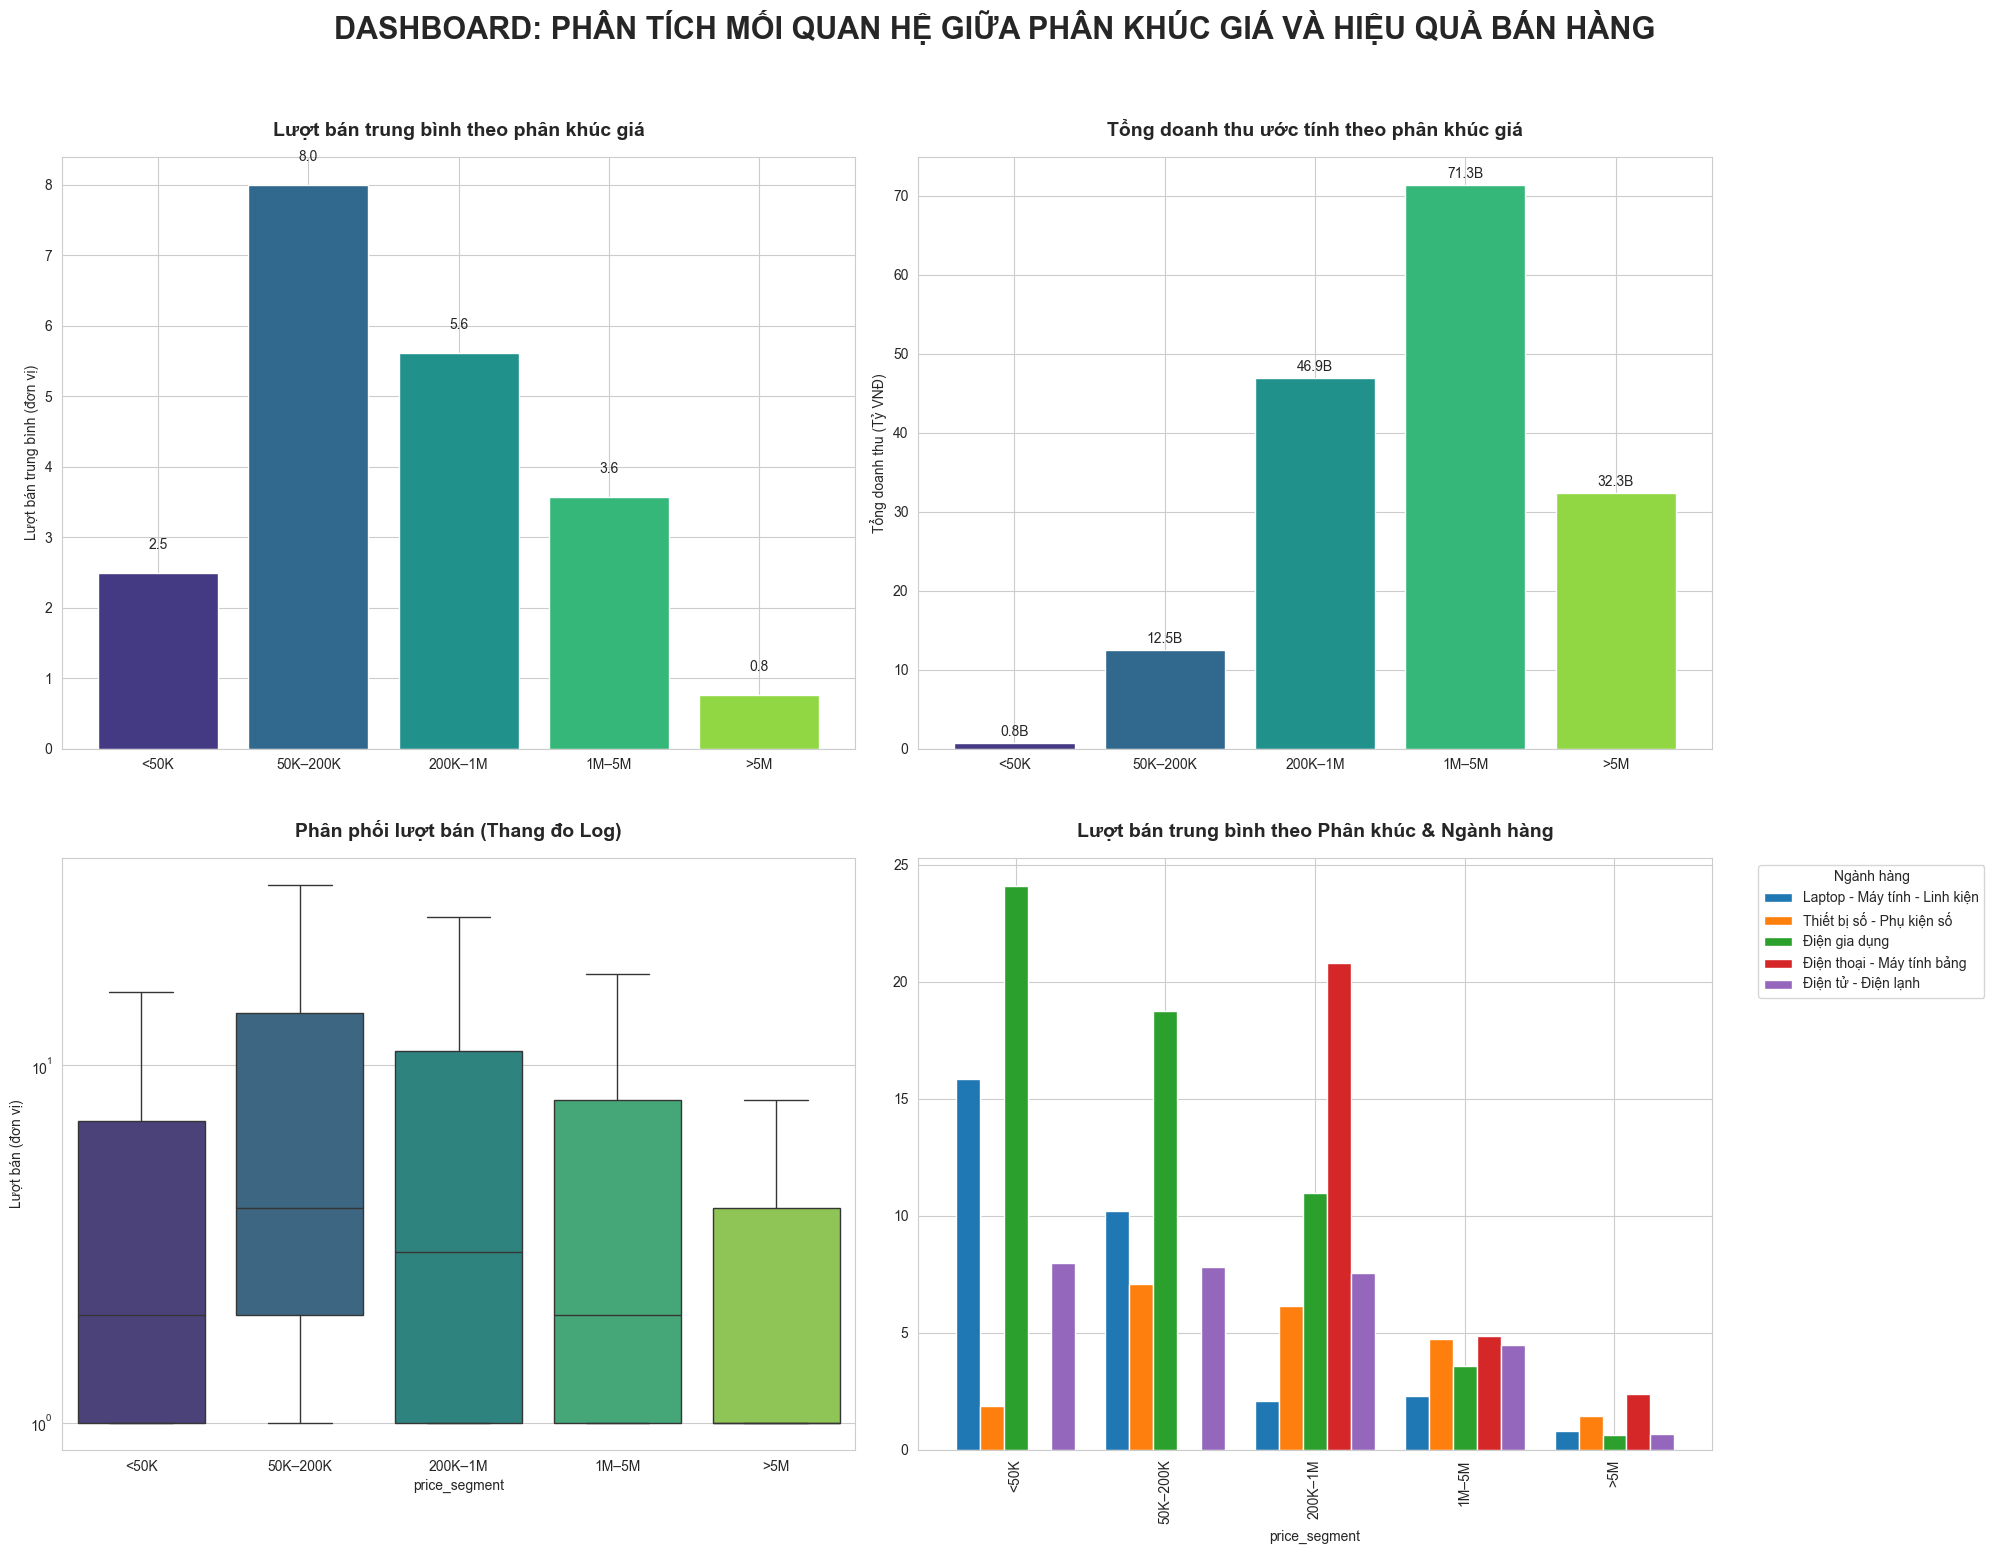

In [5]:
fig = plt.figure(figsize=(20, 22)) 
plt.suptitle('DASHBOARD: PHÂN TÍCH MỐI QUAN HỆ GIỮA PHÂN KHÚC GIÁ VÀ HIỆU QUẢ BÁN HÀNG', 
             fontsize=22, fontweight='bold', y=0.98) 

# 1. Biểu đồ: Lượt bán trung bình theo phân khúc giá
ax1 = plt.subplot2grid((3, 2), (0, 0))
colors = sns.color_palette('viridis', n_colors=5)
bars1 = ax1.bar(df_my_02['price_segment'], df_my_02['avg_sold'], color=colors, edgecolor='white')
ax1.set_title('Lượt bán trung bình theo phân khúc giá', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Lượt bán trung bình (đơn vị)')
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 0.3, f'{h:.1f}', ha='center', va='bottom')

# 2. Biểu đồ: Tổng doanh thu ước tính theo phân khúc giá
ax2 = plt.subplot2grid((3, 2), (0, 1))
bars2 = ax2.bar(df_my_02['price_segment'], df_my_02['revenue_B'], color=colors, edgecolor='white')
ax2.set_title('Tổng doanh thu ước tính theo phân khúc giá', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Tổng doanh thu (Tỷ VNĐ)')
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}B', ha='center', va='bottom')

# 3. Biểu đồ Boxplot: Phân phối lượt bán (Thang đo Log)
df_my_03 = df_my_01[df_my_01['sold_count'] > 0].copy()
ax3 = plt.subplot2grid((3, 2), (1, 0))
sns.boxplot(data=df_my_03, x='price_segment', y='sold_count', ax=ax3, 
            showfliers=False, palette='viridis') 
ax3.set_yscale('log')
ax3.set_title('Phân phối lượt bán (Thang đo Log)', fontsize=14, fontweight='bold', pad=15)
ax3.set_ylabel('Lượt bán (đơn vị)')

# 4. Biểu đồ: Lượt bán trung bình theo Phân khúc & Ngành hàng
df_my_04 = df_my_01.groupby(['price_segment', 'category_name'], observed=True)['sold_count'].mean().unstack(fill_value=0)
ax4 = plt.subplot2grid((3, 2), (1, 1))
df_my_04.plot(kind='bar', ax=ax4, width=0.8)
ax4.set_title('Lượt bán trung bình theo Phân khúc & Ngành hàng', fontsize=14, fontweight='bold', pad=15)
ax4.legend(title='Ngành hàng', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

### Key Findings – Mục tiêu 1: Tác động của phân khúc giá đến hiệu quả bán hàng

## Thiết kế Dashboard & Logic trực quan hóa

Để phân tích mối quan hệ giữa **phân khúc giá** và **hiệu quả bán hàng**, dashboard được xây dựng theo hướng từ tổng quan đến chi tiết, trong đó mỗi biểu đồ đảm nhận một vai trò riêng và bổ sung cho nhau:

- **Cặp Bar Chart (Lượt bán trung bình & Tổng doanh thu):**  
  Đây là bước phân tích ban đầu nhằm xác định xu hướng tổng thể. Hai biểu đồ được sử dụng đồng thời vì một chỉ số đơn lẻ không thể phản ánh đầy đủ hiệu quả kinh doanh. Việc đặt song song giúp so sánh trực tiếp giữa:
  - Hiệu quả theo **số lượng**
  - Hiệu quả theo **giá trị**  
  → từ đó kiểm tra liệu hai mục tiêu này có đồng nhất hay không.

- **Boxplot (phân phối lượt bán – thang log):**  
  Sau khi quan sát sự khác biệt về giá trị trung bình từ Bar Chart, cần kiểm tra liệu các giá trị này có đại diện tốt cho dữ liệu hay không. Boxplot bổ sung thông tin về:
  - Phân bố
  - Độ phân tán
  - Giá trị ngoại lệ  
  → giúp đánh giá mức độ ổn định của từng phân khúc giá.

- **Grouped Bar Chart (theo ngành hàng):**  
  Khi đã xác định sự khác biệt giữa các phân khúc giá, biểu đồ này được sử dụng để giải thích nguyên nhân bằng cách phân rã theo **ngành hàng**, từ đó làm rõ liệu hiệu quả bán hàng đến từ mức giá hay từ đặc thù sản phẩm.


→ **Pipeline phân tích:**  
**Bar Chart (xác định xu hướng) → Boxplot (kiểm chứng phân phối) → Grouped Bar (giải thích theo ngành)**

---

## Insights

### 1. Sự khác biệt giữa hiệu quả theo số lượng và doanh thu (Bar Chart)

- Phân khúc 50K – 200K có lượt bán trung bình cao nhất (~40.4 đơn/sản phẩm)  
- Phân khúc **>5M VNĐ** có lượt bán thấp nhất (~2.5 đơn/sản phẩm)  
- Tuy nhiên, phân khúc **>5M VNĐ** lại đóng góp **doanh thu cao nhất (~553.81 tỷ VNĐ)**  

→ **Liên kết hai biểu đồ:**  
Hai biểu đồ cho thấy sự không đồng nhất giữa hai thước đo hiệu quả:
- Tối ưu về số lượng ≠ tối ưu về doanh thu  

→ **Kết luận:**  
- Phân khúc trung cấp → **tăng sản lượng giao dịch**  
- Phân khúc cao cấp → **tạo giá trị doanh thu**

### 2. Độ ổn định và mức độ phân hóa (Boxplot)

- Phân khúc 50K – 200K có median cao nhất (đường gạch ngang giữa hộp nằm cao nhất trên thang log)
- Phân khúc 200K – 1M VNĐ có độ phân tán lớn (IQR rộng)

→ **Liên kết với Bar Chart:**  
Bar Chart chỉ phản ánh giá trị trung bình, trong khi Boxplot cho thấy hiệu suất cao:
- Không đồng đều  
- Bị ảnh hưởng bởi một số sản phẩm vượt trội  

→ **Kết luận:**  
Phân khúc trung cấp là nơi tập trung nhiều sản phẩm hiệu suất cao, nhưng có sự phân hóa lớn giữa các sản phẩm.


### 3. Vai trò của ngành hàng (Grouped Bar Chart)

- Ở phân khúc giá thấp (<1M VNĐ):  
  **Điện thoại - Máy tính bảng** và **Điện gia dụng** có lượt bán cao hơn rõ rệt  

- **Thiết bị số - Phụ kiện** duy trì lượt bán ổn định ở tất cả các phân khúc  

→ **Liên kết với các biểu đồ trước:**  
Biểu đồ này giải thích các xu hướng đã quan sát:
- Giá thấp bán tốt → do ngành phổ thông chiếm ưu thế  
- Giá cao vẫn có doanh thu → do ngành công nghệ duy trì nhu cầu  

→ **Kết luận:**  
Hiệu quả của phân khúc giá phụ thuộc vào **cấu trúc ngành hàng**, không chỉ riêng mức giá.


### 4. Đánh giá mối quan hệ giá – lượt bán

- Từ Bar Chart:  
  → Giá càng cao → lượt bán trung bình có xu hướng giảm  

- Từ Boxplot:  
  → Các phân khúc giá cao vẫn có phân phối ổn định  
  → Không có dấu hiệu mất hoàn toàn nhu cầu  

→ **Liên kết hai biểu đồ:**  
- Bar Chart: cung cấp xu hướng tổng thể  
- Boxplot: cho thấy xu hướng này **không đồng đều trong toàn bộ dữ liệu**  

→ **Kết luận:**  
Giá có ảnh hưởng đến lượt bán ở cấp độ trung bình, nhưng **không phải yếu tố quyết định duy nhất**

---

## Kết luận chung

### 1. Tổng hợp phát hiện

- Tồn tại sự khác biệt rõ ràng giữa **sản lượng** và **doanh thu** (Bar Chart)  
- Sự khác biệt này được **kiểm chứng về phân phối** (Boxplot)  
- Và được **giải thích bởi ngành hàng** (Grouped Bar Chart)  

→ **Kết luận nhất quán:**  
Hiệu quả bán hàng là kết quả của sự kết hợp giữa **phân khúc giá** và **đặc thù ngành hàng**


### 2. Đề xuất

- **Tối ưu lượt bán:**  
  → Tập trung vào phân khúc **50K – 200K** và **200K – 1M VNĐ**  

- **Tối ưu doanh thu:**  
  → Khai thác phân khúc **>5M VNĐ**, đặc biệt với ngành công nghệ  

- **Chiến lược theo ngành:**  
  - Ngành phổ thông → định giá thấp–trung để tăng lượt bán  
  - Ngành công nghệ → có thể duy trì giá cao để tối ưu doanh thu  


## 3. Mục tiêu 2: Tác động của tỷ lệ giảm giá đến việc kích cầu
Tỷ lệ giảm giá ảnh hưởng như thế nào đến việc kích cầu (lượt bán), và liệu hiệu quả này có khác biệt giữa các mức giảm giá và giữa các ngành hàng hay không?

## Mục tiêu SMART: ##

- Specific: Xác định ngưỡng giảm giá (Discount Threshold) tạo ra sự thay đổi ý nghĩa về mặt thống kê đối với lượt bán của sản phẩm.

- Measurable: Sử dụng các kiểm định phi tham số (Kruskal-Wallis, Mann-Whitney U) và trực quan hóa qua biểu đồ Heatmap (Ngành hàng x Ngưỡng giảm giá).

- Achievable: Thực hiện bóc tách dữ liệu và chạy các mô hình kiểm định trên toàn bộ dataset hiện có.

- Relevant: Cung cấp bằng chứng thực tế để tối ưu hóa hiệu quả của các chương trình khuyến mãi và Flash Sale.

- Time-bound: Kết quả được giới hạn trong khung thời gian của tập dữ liệu snapshot hiện hành, tập trung bóc tách các xu hướng khuyến mãi đặc thù tại thời điểm báo cáo để đưa ra các đề xuất chiến lược kịp thời.

In [6]:
df_my_06 = df_product.copy()
df_my_06 = df_product.copy()

if 'source_category' not in df_my_06.columns:
    df_my_06 = pd.merge(df_my_06, df_category[['category_id', 'source_category']], on='category_id', how='left')
# Filter valid data
df_my_06 = df_my_06[
    (df_my_06['price'] > 0) &
    (df_my_06['original_price'] > 0) &
    (df_my_06['source_category'].notna())
].copy()

df_my_06['category_name'] = df_my_06['source_category'].map(category_mapping)
df_my_06 = df_my_06[df_my_06['category_name'].notna()]

# Create discount bins
disc_labels = ['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '> 50%']
df_my_06['disc_bin'] = pd.cut(
    df_my_06['discount_percent'],
    bins=[-0.1, 0, 10, 20, 30, 40, 50, 100],
    labels=disc_labels
)

df_my_06['est_revenue'] = df_my_06['price'] * df_my_06['sold_count']

print(f"Tổng số sản phẩm đưa vào phân tích: {len(df_my_06)}")
print(f"\nPhân bố theo nhóm giảm giá:")
print(df_my_06['disc_bin'].value_counts().sort_index())

Tổng số sản phẩm đưa vào phân tích: 54765

Phân bố theo nhóm giảm giá:
disc_bin
0%        42640
1-10%      1425
11-20%     2047
21-30%     2996
31-40%     4941
41-50%      531
> 50%       185
Name: count, dtype: int64


In [7]:
# --- df_my_07: Aggregate statistics by discount bin ---
df_my_07 = df_my_06.groupby('disc_bin', observed=True).agg(
    product_count=('product_id', 'count'),
    avg_sold=('sold_count', 'mean'),
    median_sold=('sold_count', 'median'),
    total_sold=('sold_count', 'sum'),
    total_revenue=('est_revenue', 'sum')
).reset_index()

df_my_07['revenue_B'] = df_my_07['total_revenue'] / 1e9
print("=== Bảng thống kê tóm tắt theo nhóm giảm giá ===")
print(df_my_07[['disc_bin', 'product_count', 'avg_sold', 'median_sold', 'total_sold', 'revenue_B']].to_string(index=False))

=== Bảng thống kê tóm tắt theo nhóm giảm giá ===
disc_bin  product_count  avg_sold  median_sold  total_sold  revenue_B
      0%          42640  4.894747          0.0      208712 109.569768
   1-10%           1425  7.753684          0.0       11049   7.510480
  11-20%           2047  5.415730          0.0       11086  11.479558
  21-30%           2996  3.811081          0.0       11418  11.383402
  31-40%           4941  1.874519          0.0        9262  11.299736
  41-50%            531 14.508475          1.0        7704   6.651167
   > 50%            185 29.172973         12.0        5397   5.986754


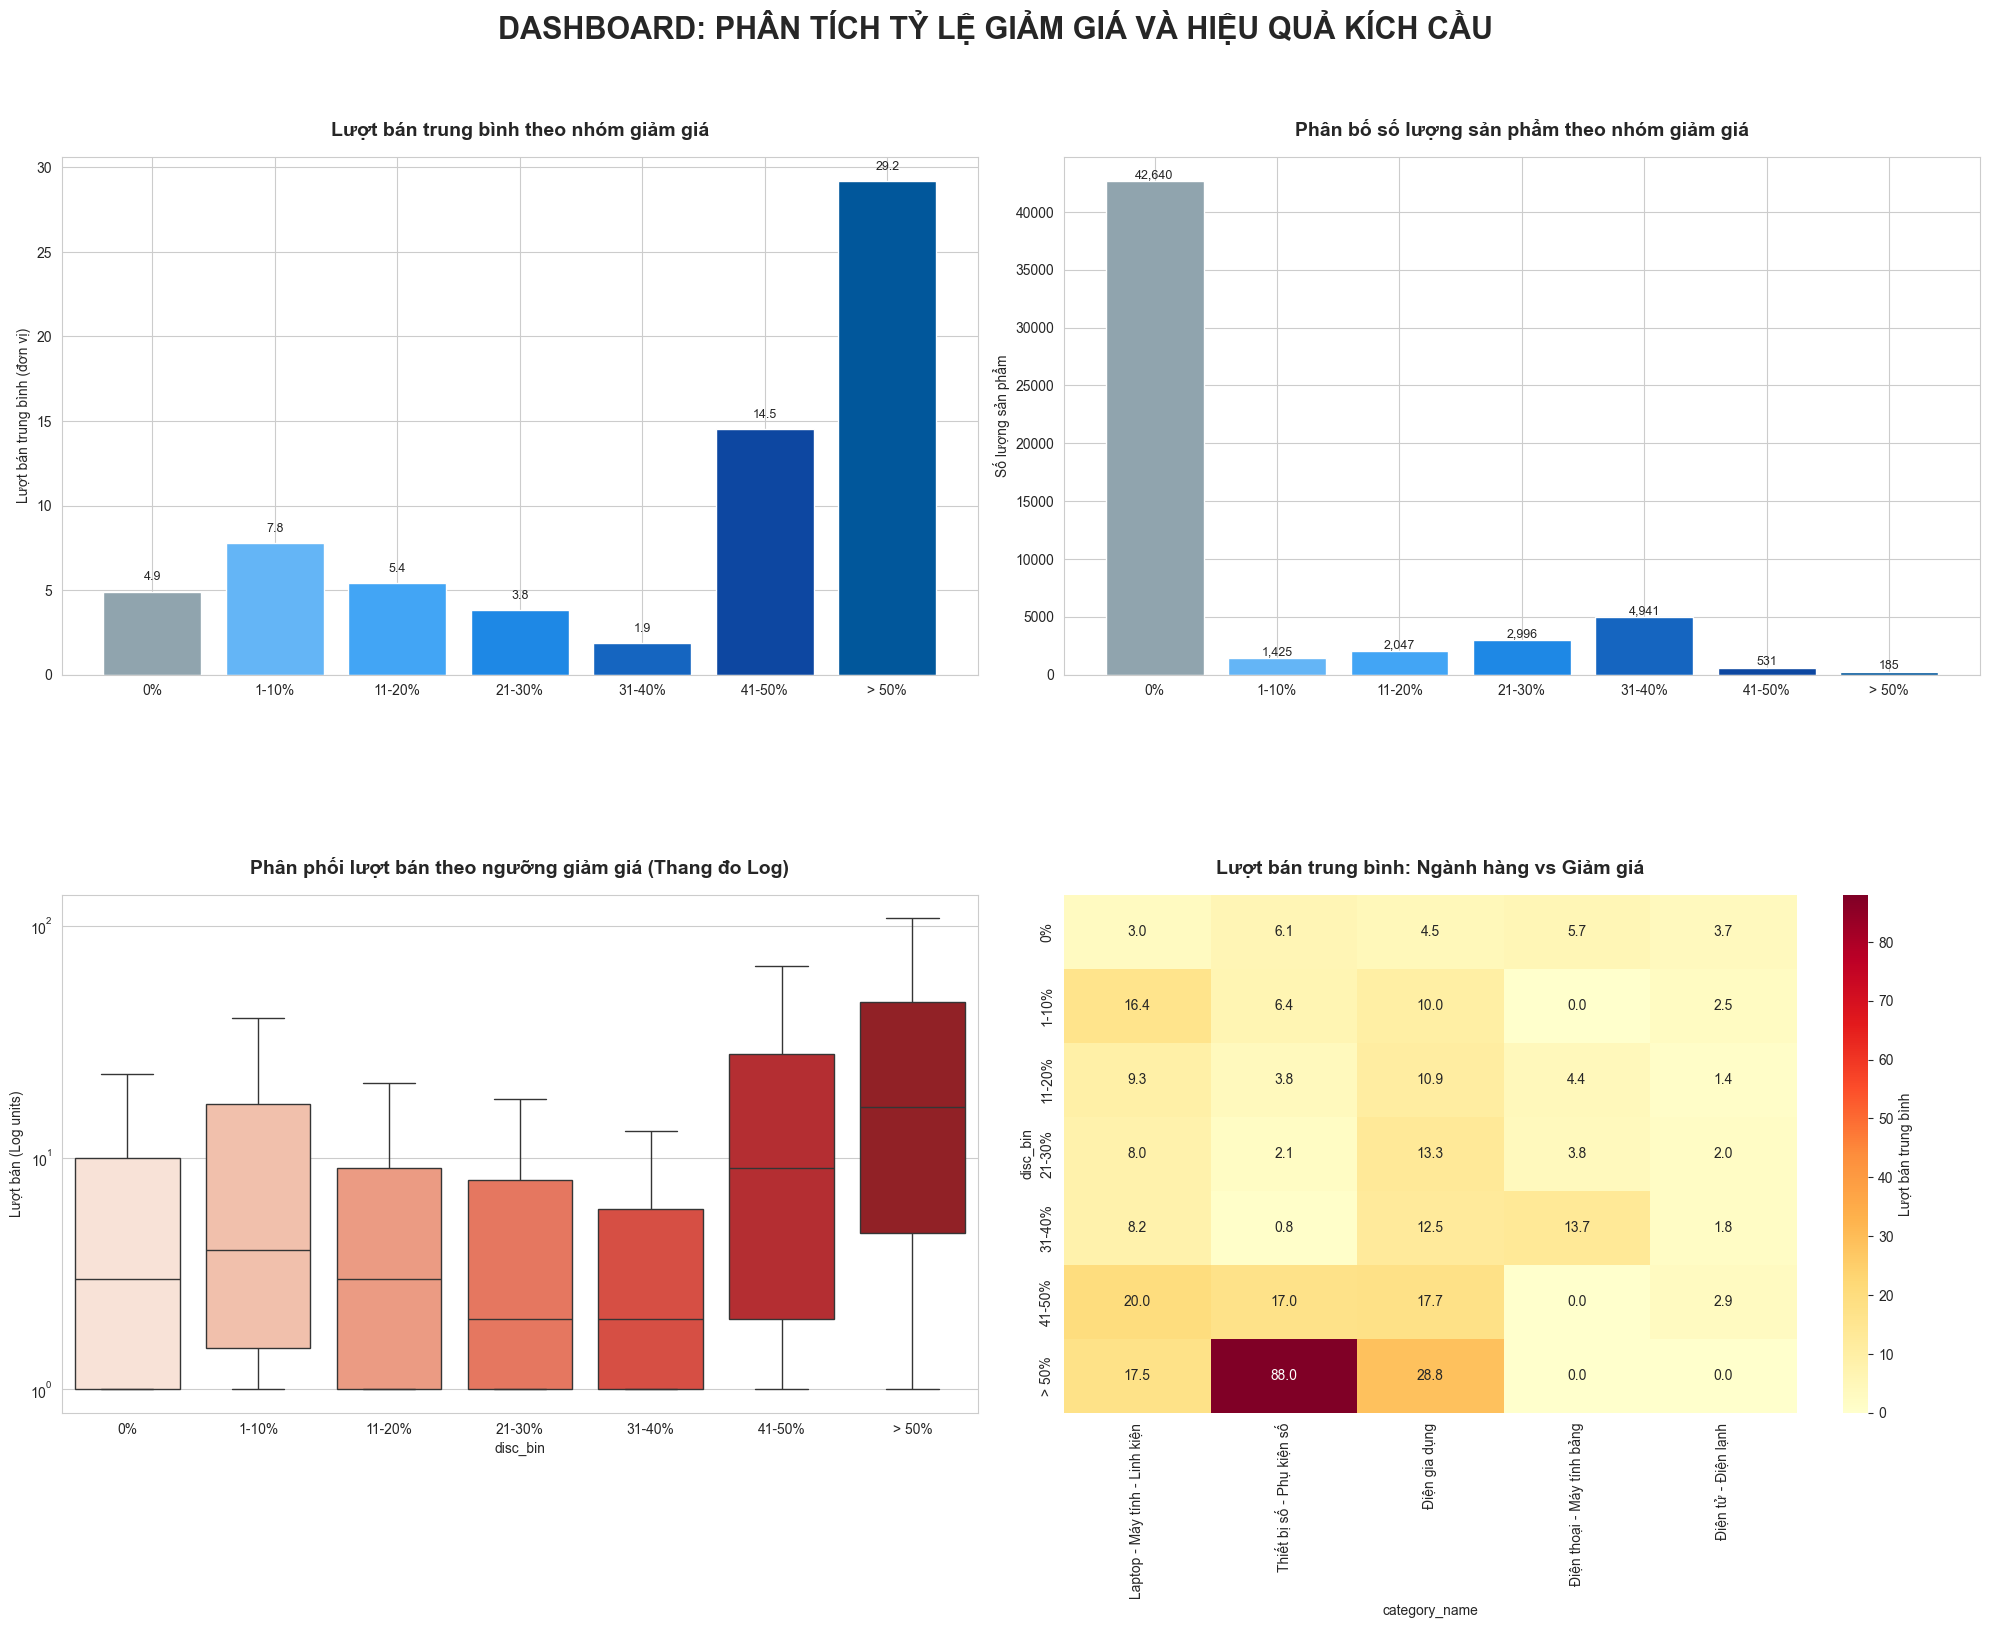

In [8]:
fig = plt.figure(figsize=(20, 22))
plt.suptitle('DASHBOARD: PHÂN TÍCH TỶ LỆ GIẢM GIÁ VÀ HIỆU QUẢ KÍCH CẦU', 
             fontsize=22, fontweight='bold', y=0.98)

# 1. Biểu đồ: Lượt bán trung bình theo nhóm giảm giá
ax1 = plt.subplot2grid((3, 2), (0, 0))
disc_colors = ['#90A4AE', '#64B5F6', '#42A5F5', '#1E88E5', '#1565C0', '#0D47A1', '#01579B']
bars1 = ax1.bar(df_my_07['disc_bin'], df_my_07['avg_sold'], color=disc_colors, edgecolor='white')
#ax1.plot(range(len(df_my_07)), df_my_07['avg_sold'], color='red', marker='o', linewidth=2, label='Xu hướng')
ax1.set_title('Lượt bán trung bình theo nhóm giảm giá', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Lượt bán trung bình (đơn vị)')
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}', ha='center', va='bottom', fontsize=9)

# 2. Biểu đồ: Số lượng sản phẩm theo nhóm giảm giá
ax2 = plt.subplot2grid((3, 2), (0, 1))
bars2 = ax2.bar(df_my_07['disc_bin'], df_my_07['product_count'], color=disc_colors, edgecolor='white')
ax2.set_title('Phân bố số lượng sản phẩm theo nhóm giảm giá', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Số lượng sản phẩm')
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h + 10, f'{int(h):,}', ha='center', va='bottom', fontsize=9)

# 3. Biểu đồ Boxplot: Phân phối lượt bán theo ngưỡng giảm giá (Thang đo Log)
df_my_08 = df_my_06[df_my_06['sold_count'] > 0].copy()
ax3 = plt.subplot2grid((3, 2), (1, 0))
sns.boxplot(data=df_my_08, x='disc_bin', y='sold_count', ax=ax3, showfliers=False, palette='Reds')
ax3.set_yscale('log')
ax3.set_title('Phân phối lượt bán theo ngưỡng giảm giá (Thang đo Log)', fontsize=14, fontweight='bold', pad=15)
ax3.set_ylabel('Lượt bán (Log units)')

# 4. Heatmap: Ngành hàng và Tỷ lệ giảm giá
df_my_10 = df_my_06.groupby(['disc_bin', 'category_name'], observed=True)['sold_count'].mean().unstack(fill_value=0)
ax4 = plt.subplot2grid((3, 2), (1, 1))
sns.heatmap(df_my_10, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Lượt bán trung bình'})
ax4.set_title('Lượt bán trung bình: Ngành hàng vs Giảm giá', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Key Findings – Mục tiêu 2: Tác động của tỷ lệ giảm giá đến việc kích cầu lượt bán

## Thiết kế Dashboard & Logic trực quan hóa

Để phân tích mối quan hệ giữa **mức giảm giá** và **hiệu quả kích cầu (lượt bán)**, dashboard được xây dựng theo trình tự từ tổng quan đến chi tiết, trong đó mỗi biểu đồ đóng vai trò kiểm chứng và bổ sung cho nhau:

- **Bar Chart (Lượt bán trung bình theo nhóm giảm giá):**  
  Được sử dụng để xác định xu hướng tổng thể: mức giảm giá có giúp tăng lượt bán hay không. Tuy nhiên, chỉ nhìn vào giá trị trung bình có thể gây hiểu sai nếu số lượng sản phẩm trong từng nhóm không đồng đều.

- **Bar Chart (Số lượng sản phẩm theo nhóm giảm giá):**  
  Biểu đồ này được thêm vào để kiểm tra **quy mô dữ liệu** trong từng nhóm giảm giá. Nó giúp trả lời câu hỏi: liệu mức giảm giá cao có thực sự hiệu quả, hay chỉ là kết quả từ số lượng mẫu nhỏ.

→ **Hai biểu đồ này cần được đọc cùng nhau:**  
- Biểu đồ 1: phản ánh **hiệu quả**  
- Biểu đồ 2: kiểm chứng **độ tin cậy của hiệu quả (quy mô mẫu)**

- **Boxplot (phân phối lượt bán – thang log):**  
  Sau khi xác định xu hướng trung bình, Boxplot được sử dụng để kiểm tra **độ ổn định và phân bố** trong từng nhóm giảm giá. Điều này giúp xác định liệu hiệu quả kích cầu có đồng đều hay chỉ đến từ một số trường hợp đặc biệt.

- **Heatmap (Ngành hàng × Mức giảm giá):**  
  Khi đã thấy sự khác biệt giữa các nhóm giảm giá, cần phân tích sâu hơn theo ngành hàng để giải thích nguyên nhân. Heatmap cho phép quan sát đồng thời hai chiều, từ đó xác định nhóm nào phản ứng tốt nhất với chiến lược giảm giá.


→ **Pipeline phân tích:**  
**Bar Chart (xu hướng) → Bar Chart (kiểm chứng quy mô) → Boxplot (phân phối) → Heatmap (giải thích theo ngành)**

---

## Insights

### 1. Xu hướng giữa giảm giá và lượt bán (Bar Chart)

- Nhóm **>50% giảm giá** có lượt bán trung bình cao nhất (~29.2 đơn/sản phẩm)  
- Nhóm **31–40%** có lượt bán thấp nhất (~2 đơn/sản phẩm)  
- Các nhóm **0–20%** có mức lượt bán dao động nhưng không vượt trội  

→ **Nhận xét:**  
Không tồn tại xu hướng tăng đều giữa mức giảm giá và lượt bán. Hiệu quả kích cầu chỉ tăng mạnh ở mức giảm giá rất cao (**>50%**), trong khi các mức trung gian không tạo ra cải thiện rõ rệt.


### 2. Kiểm chứng quy mô dữ liệu (Bar Chart – số lượng sản phẩm)

- Nhóm **0% giảm giá** chiếm số lượng lớn nhất (~42,000 sản phẩm)  
- Nhóm **>50% giảm giá** có số lượng rất nhỏ (~185 sản phẩm)  

→ **Liên kết với biểu đồ trước:**  
Mặc dù nhóm >50% có hiệu suất cao, nhưng quy mô mẫu nhỏ → kết quả **không đại diện cho toàn bộ hệ thống**

→ **Kết luận:**  
Hiệu quả ở mức giảm giá cao cần được diễn giải thận trọng do hạn chế về dữ liệu.


### 3. Độ ổn định của hiệu quả kích cầu (Boxplot)

- Nhóm **>50%** có median cao và phân phối tập trung hơn  
- Các nhóm giảm giá thấp có phân phối rộng và median thấp hơn  

→ **Liên kết với Bar Chart:**  
Boxplot xác nhận hiệu suất cao của nhóm >50% không chỉ là outlier, mà xuất hiện trong toàn bộ phân phối.

→ **Kết luận:**  
Giảm giá sâu có thể tạo hiệu quả kích cầu rõ rệt, nhưng chỉ trong phạm vi nhóm sản phẩm nhỏ.


### 4. Sự khác biệt theo ngành hàng (Heatmap)

- Một số ngành như **Điện gia dụng** và **Laptops & Linh kiện** đạt hiệu quả cao ở mức giảm giá >50%  
- Nhiều ngành khác không cải thiện đáng kể dù tăng mức giảm giá  

→ **Liên kết với các biểu đồ trước:**  
Heatmap giải thích vì sao hiệu quả giảm giá không đồng đều:
- Không phải mọi ngành đều phản ứng giống nhau  
- Hiệu quả cao tập trung ở một số ngành cụ thể  

→ **Kết luận:**  
Tác động của giảm giá phụ thuộc mạnh vào **ngành hàng**

---

## Kết luận chung

### 1. Tổng hợp phát hiện

- Hiệu quả kích cầu **không tăng tuyến tính** theo mức giảm giá  
- Kết quả ở mức giảm giá cao bị giới hạn bởi **quy mô mẫu nhỏ**  
- Hiệu quả cao được **xác nhận về phân phối** (Boxplot)  
- Và được **giải thích bởi ngành hàng** (Heatmap)  

→ **Kết luận nhất quán:**  
Giảm giá >50% cho thấy hiệu quả kích cầu rõ rệt trong dữ liệu quan sát, tuy nhiên cần thận trọng khi khái quát do quy mô mẫu nhỏ.

### 2. Đề xuất

- **Không lạm dụng giảm giá trung bình (10–40%)**  
  → Không tạo ra cải thiện đáng kể về lượt bán  

- **Chiến lược giảm giá mạnh (deep discount)**  
  → Áp dụng **>50%** cho sản phẩm chiến lược  
  → Không triển khai đại trà do:
  - Quy mô nhỏ  
  - Rủi ro lợi nhuận  

- **Tối ưu theo ngành hàng**  
  → Xác định ngành phản ứng tốt với giảm giá  
  → Áp dụng chiến lược có chọn lọc thay vì đồng loạt  

## 4. CHIẾN LƯỢC ĐỊNH GIÁ VÀ KHUYẾN MÃI TÍCH HỢP
### KẾT LUẬN CHUNG

Dựa trên kết quả phân tích từ hai khía cạnh chính: **phân khúc giá** và **tỷ lệ giảm giá**, có thể rút ra các kết luận tích hợp như sau:

---

### 1. Mối quan hệ giữa Định giá và Kích cầu

**Bằng chứng từ dữ liệu:**
- Phân khúc **50K – 100K VNĐ** ghi nhận lượt bán trung bình cao nhất và chứa nhiều sản phẩm có hiệu suất vượt trội (theo Boxplot).
- Hiệu quả kích cầu chỉ tăng rõ rệt ở mức giảm giá rất cao (**>50%**).
- Các mức giảm giá trung bình (**10–40%**) không tạo ra sự cải thiện đáng kể về lượt bán.
- Nhóm **>50% giảm giá** có quy mô sản phẩm nhỏ → tính đại diện thấp.

**Kết luận:**
Không tồn tại mối quan hệ tuyến tính đơn giản giữa giá và giảm giá.  
Hiệu quả bán hàng chỉ được tối ưu khi:
- Giá nằm trong phân khúc phù hợp với nhu cầu
- Giảm giá được áp dụng đúng mức và đúng ngữ cảnh

**Hàm ý:** Giảm giá không thể thay thế cho chiến lược định giá.

---

### 2. Chiến lược phân hóa theo mục tiêu kinh doanh

#### (1) Chiến lược tối ưu sản lượng (Volume-driven)

**Bằng chứng:**
- Phân khúc **<1M VNĐ** có lượt bán cao nhất
- Các ngành phổ thông (Home Appliances, Digital Devices) chiếm ưu thế
- Boxplot cho thấy tồn tại nhiều sản phẩm bán vượt trội

**Định hướng:**
- Tập trung vào phân khúc **50K – 1M VNĐ**
- Giảm giá không phải yếu tố quyết định chính

**Mục tiêu:** Tăng số lượng đơn hàng


#### (2) Chiến lược tối ưu doanh thu (Revenue-driven)

**Bằng chứng:**
- Phân khúc **>5M VNĐ** tạo ra doanh thu cao nhất
- Một số ngành (Laptops & Components) duy trì hiệu suất ở mọi mức giá
- Giảm giá sâu chỉ hiệu quả trong một số ngành cụ thể

**Định hướng:**
- Tập trung vào sản phẩm giá trị cao
- Chỉ áp dụng giảm giá sâu (**>50%**) trong trường hợp chọn lọc

**Mục tiêu:** Tối đa hóa doanh thu


### 3. Vai trò của ngành hàng

**Bằng chứng:**
- Ngành phổ thông hiệu quả ở giá thấp
- Ngành công nghệ duy trì hiệu quả ở giá cao và giảm giá sâu

**Kết luận:**
Hiệu quả của giá và giảm giá phụ thuộc vào **đặc thù ngành hàng**

**Hàm ý:** Không thể áp dụng một chiến lược chung cho tất cả sản phẩm


### 4. Giá trị của phân tích dựa trên dữ liệu

Các kết luận được xây dựng dựa trên:
- So sánh xu hướng (Bar Chart)
- Kiểm chứng phân phối (Boxplot)
- Phân rã theo ngành (Grouped Bar, Heatmap)

**Ý nghĩa:**
Các giả định phổ biến như “giảm giá luôn làm tăng lượt bán” không đúng trong mọi trường hợp.

---

## Đề xuất chiến lược

| Yếu tố | Đề xuất tối ưu | Ý nghĩa chiến lược |
|--------|--------------|------------------|
| **Phân khúc giá** | 200K – 1M VNĐ | Tối ưu lượt bán |
| **Phân khúc cao cấp** | >5M VNĐ | Tối đa hóa doanh thu |
| **Mức giảm giá** | >50% (có chọn lọc) | Kích cầu mạnh trong phạm vi hẹp |
| **Ngành hàng** | Phân tách theo từng ngành | Tối ưu theo đặc thù sản phẩm |
